In [1]:
# Install all dependencies.
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [28]:
# Required Imports
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from mlops import MLflowExperimentManager
import warnings
warnings.filterwarnings('ignore')

In [26]:
# Fraud Detection Project Class
class FraudDetectionProject:
    def __init__(self, use_local=False):
        self.dataset_url = 'https://www.kaggle.com/mlg-ulb/creditcardfraud/download'
        self.dataset_path = 'data/creditcard.csv'
        self.model_path = 'models/fraud_detection_model.pkl'
        self.use_local = use_local
        self.spark = None
        self.df_spark = None
        self.df_pandas = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.models = {}
        self.results = {}
        self.best_model = None

        if not self.use_local and SparkSession is not None:
            self.spark = SparkSession.builder.appName("FraudDetection").getOrCreate()
    
    def load_data(self):
        if not self.use_local and self.spark is not None:
            self.df_spark = self.spark.read.csv(self.dataset_path, header=True, inferSchema=True)
        else:
            self.df_pandas = pd.read_csv(self.dataset_path)
    
    def preprocess_data(self):
        if not self.use_local and self.spark is not None:
            self.df_spark = self.df_spark.withColumn("Class", col("Class").cast("integer"))
            fraud_cases = self.df_spark.filter(self.df_spark['Class'] == 1)
            non_fraud_cases = self.df_spark.filter(self.df_spark['Class'] == 0).sample(fraction=0.1)
            balanced_data = fraud_cases.union(non_fraud_cases)
            self.df_pandas = balanced_data.toPandas()
        else:
            fraud_cases = self.df_pandas[self.df_pandas['Class'] == 1]
            non_fraud_cases = self.df_pandas[self.df_pandas['Class'] == 0].sample(frac=0.1, random_state=42)
            self.df_pandas = pd.concat([fraud_cases, non_fraud_cases])

        X = self.df_pandas.drop(columns=['Class'])
        y = self.df_pandas['Class']
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )
    
    def train_model(self, model_name, model, param_grid=None):
        if param_grid:
            grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=1)
            grid_search.fit(self.X_train, self.y_train)
            self.models[model_name] = grid_search.best_estimator_
        else:
            model.fit(self.X_train, self.y_train)
            self.models[model_name] = model
    
    def evaluate_model(self, model_name):
        model = self.models[model_name]
        y_pred = model.predict(self.X_test)
        self.results[model_name] = {
            'confusion_matrix': confusion_matrix(self.y_test, y_pred),
            'classification_report': classification_report(self.y_test, y_pred),
            'accuracy_score': accuracy_score(self.y_test, y_pred),
            'y_pred': y_pred
        }

        if hasattr(model, 'predict_proba'):
            y_score = model.predict_proba(self.X_test)[:, 1]
        elif hasattr(model, 'decision_function'):
            y_score = model.decision_function(self.X_test)
        else:
            y_score = None

        if y_score is not None:
            self.results[model_name]['roc_auc'] = roc_auc_score(self.y_test, y_score)

    def print_results(self, model_name):
        for result_key, result in self.results[model_name].items():
            print(f'{result_key.replace("_", " ").title()}:\n{result}')

    def summarize_model_metrics(self):
        """Return fraud-class metrics for every trained model."""
        metrics = []

        for model_name, model in self.models.items():
            y_pred = self.results[model_name]['y_pred']
            report = classification_report(
                self.y_test,
                y_pred,
                output_dict=True,
                zero_division=0
            )

            metrics.append({
                'model': model_name,
                'accuracy': report['accuracy'],
                'fraud_precision': report['1']['precision'],
                'fraud_recall': report['1']['recall'],
                'fraud_f1': report['1']['f1-score'],
                'roc_auc': self.results[model_name].get('roc_auc', np.nan)
            })

        return pd.DataFrame(metrics).set_index('model').sort_values(
            'fraud_recall', ascending=False
        )

    def select_best_model(self, metrics, metric='fraud_recall'):
        """Select and return the model name with the highest metric value."""
        if metric not in metrics.columns:
            raise ValueError(f"Unknown metric '{metric}'. Choose from: {list(metrics.columns)}")

        self.best_model = metrics[metric].idxmax()
        print(f"Best model by {metric}: {self.best_model} ({metrics.loc[self.best_model, metric]:.4f})")
        return self.best_model

    def save_model(self, model_name=None):
        """Save a trained model and return the output path."""
        model_name = model_name or self.best_model
        if model_name is None:
            raise ValueError('Select a best model before saving.')
        if model_name not in self.models:
            raise ValueError(f"Model '{model_name}' has not been trained.")

        joblib.dump(self.models[model_name], self.model_path)
        print(f"Saved {model_name} to: {self.model_path}")
        return self.model_path

    def load_model(self, model_path=None):
        """Load a saved model and make it the active model."""
        self.model_path = model_path or self.model_path
        self.models['loaded'] = joblib.load(self.model_path)
        self.best_model = 'loaded'
        return self.models['loaded']

    def predict(self, X, threshold=0.5):
        """Predict fraud labels with the active model and threshold."""
        if self.best_model is None or self.best_model not in self.models:
            raise ValueError('Load or select a model before making predictions.')

        model = self.models[self.best_model]
        if threshold == 0.5:
            return model.predict(X)
        if not hasattr(model, 'predict_proba'):
            raise ValueError('A custom threshold requires a model with predict_proba().')

        probabilities = model.predict_proba(X)[:, 1]
        return (probabilities >= threshold).astype(int)

    def evaluate_predictions(self, X, y, threshold=0.5):
        """Evaluate the active model on supplied labeled data."""
        y_pred = self.predict(X, threshold=threshold)
        return {
            'confusion_matrix': confusion_matrix(y, y_pred),
            'classification_report': classification_report(y, y_pred, zero_division=0),
            'accuracy_score': accuracy_score(y, y_pred),
            'y_pred': y_pred
        }

    def visualize_learning_curves(self, model_name):
        train_sizes, train_scores, test_scores = learning_curve(
            self.models[model_name],
            self.X_train, self.y_train,
            cv=5, scoring='accuracy', n_jobs=-1
        )
        plt.figure(figsize=(25.6, 16))
        plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='r', label='Training score')
        plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color='g', label='Validation score')
        plt.xlabel('Training examples')
        plt.ylabel('Score')
        plt.title(f'Learning Curves for {model_name}')
        plt.legend(loc='best')
        plt.show()
    
    def visualize_confusion_matrix(self, model_name):
        matrix = self.results[model_name]['confusion_matrix']
        sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
        plt.title(f"Confusion Matrix for {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

    def visualize_correlation_heatmap(self):
        correlation_matrix = self.df_pandas.corr()
        plt.figure(figsize=(25.6, 16))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
        plt.title("Correlation Heatmap")
        plt.show()
    
    def run_experiments(self):
        param_grid_rf = {
            'n_estimators': [100, 200],
            'max_depth': [10, 20],
            'min_samples_split': [2, 5]
        }
        self.train_model("RandomForest", RandomForestClassifier(), param_grid_rf)
        self.evaluate_model("RandomForest")
        
        param_grid_gb = {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 5]
        }
        self.train_model("GradientBoosting", GradientBoostingClassifier(), param_grid_gb)
        self.evaluate_model("GradientBoosting")
        
        self.train_model("LogisticRegression", LogisticRegression(max_iter=1000))
        self.evaluate_model("LogisticRegression")
        
        param_grid_svm = {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf']
        }
        self.train_model("SVM", SVC(), param_grid_svm)
        self.evaluate_model("SVM")
        
        param_grid_knn = {
            'n_neighbors': [3, 5, 7],
            'weights': ['uniform', 'distance']
        }
        self.train_model("KNN", KNeighborsClassifier(), param_grid_knn)
        self.evaluate_model("KNN")
    
    def visualize_all_results(self):
        for model_name in self.models.keys():
            self.print_results(model_name)
            self.visualize_confusion_matrix(model_name)
    
    def compare_accuracies(self):
        model_names = list(self.results.keys())
        accuracies = [self.results[model]['accuracy_score'] for model in model_names]
        min_accuracy = min(accuracies) - 0.01
        max_accuracy = max(accuracies) + 0.01
        
        fig = go.Figure(data=[
            go.Bar(name='Accuracy', x=model_names, y=accuracies, marker_color='blue')
        ])
        fig.update_layout(
            title='Model Comparison - Accuracy Scores',
            xaxis_title='Model',
            yaxis_title='Accuracy',
            yaxis=dict(range=[max(0, min_accuracy), min(1, max_accuracy)]),
            template='plotly_white'
        )
        fig.show()

## Local Execution

In [14]:
# Create an instance of the project with the `use_local` flag
# Set use_local=True to run locally, use_local=False to run with Spark
fraud_project = FraudDetectionProject(use_local = True)

# Load data and initialize
fraud_project.load_data()

In [15]:
# Preprocess the data and split into training and testing sets
fraud_project.preprocess_data()

In [16]:
# Run experiments with various algorithms
fraud_project.run_experiments()

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits


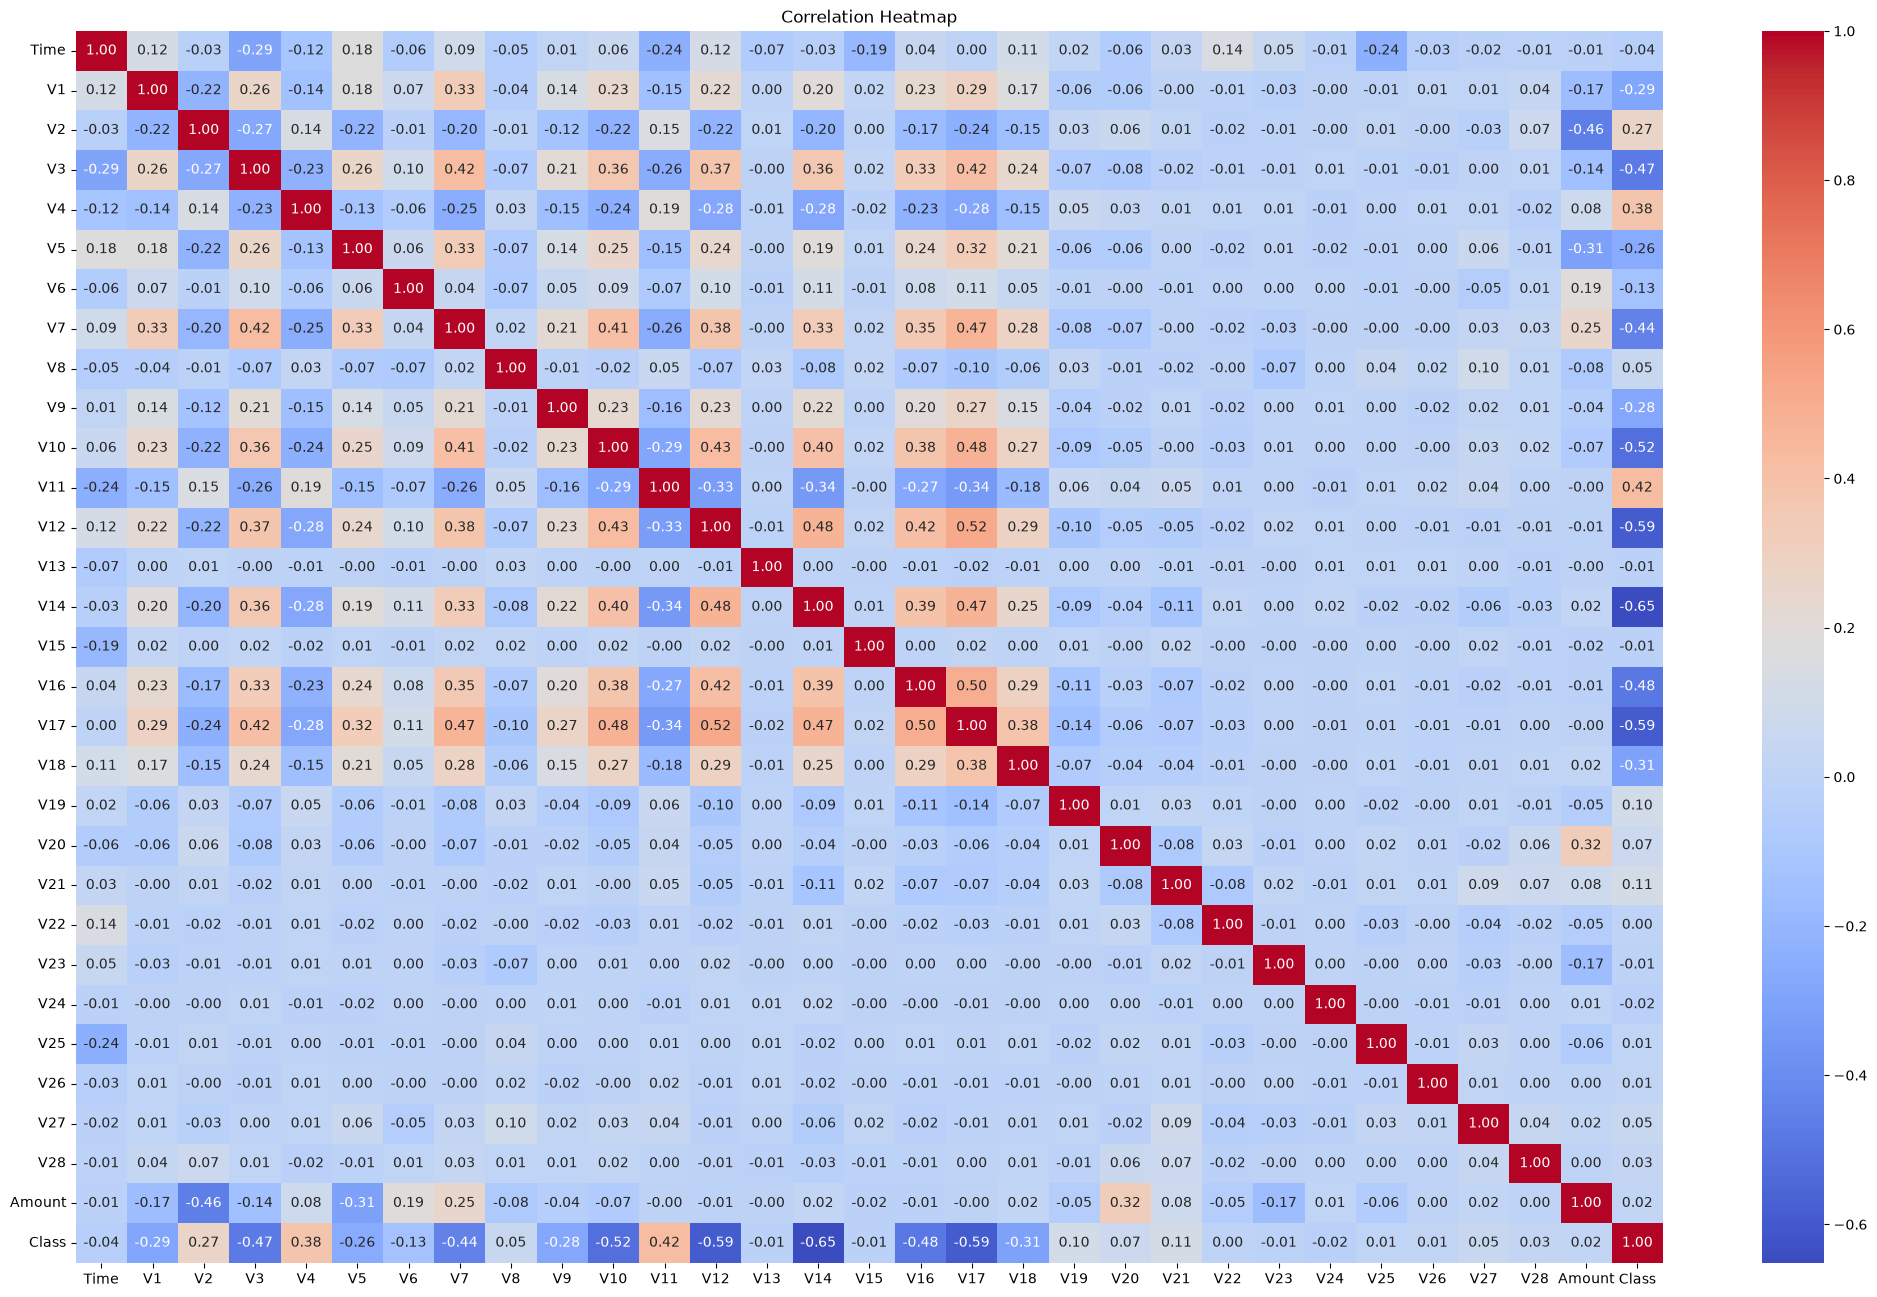

Confusion Matrix:
[[8528    4]
 [  25  121]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8532
           1       0.97      0.83      0.89       146

    accuracy                           1.00      8678
   macro avg       0.98      0.91      0.95      8678
weighted avg       1.00      1.00      1.00      8678

Accuracy Score:
0.9966582161788431
Y Pred:
[0 0 0 ... 0 0 0]
Roc Auc:
0.9795162771580319


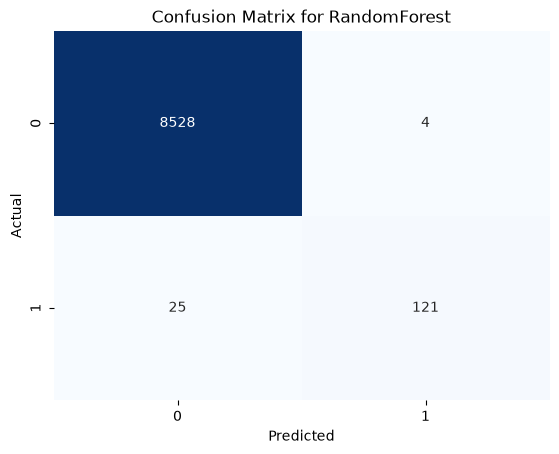

Confusion Matrix:
[[8529    3]
 [  25  121]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8532
           1       0.98      0.83      0.90       146

    accuracy                           1.00      8678
   macro avg       0.99      0.91      0.95      8678
weighted avg       1.00      1.00      1.00      8678

Accuracy Score:
0.9967734501037105
Y Pred:
[0 0 0 ... 0 0 0]
Roc Auc:
0.9667966366748229


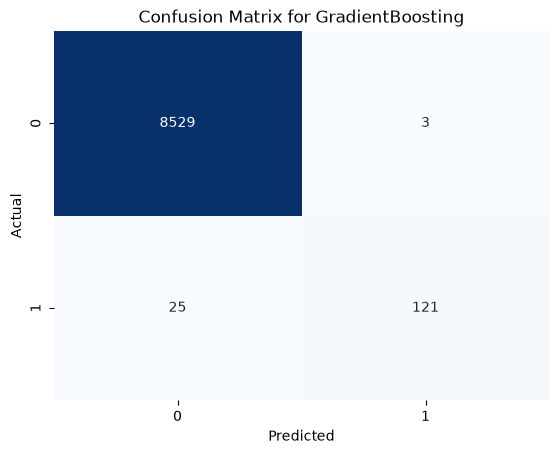

Confusion Matrix:
[[8526    6]
 [  34  112]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8532
           1       0.95      0.77      0.85       146

    accuracy                           1.00      8678
   macro avg       0.97      0.88      0.92      8678
weighted avg       1.00      1.00      1.00      8678

Accuracy Score:
0.9953906430053008
Y Pred:
[0 0 0 ... 0 0 0]
Roc Auc:
0.9451388487499117


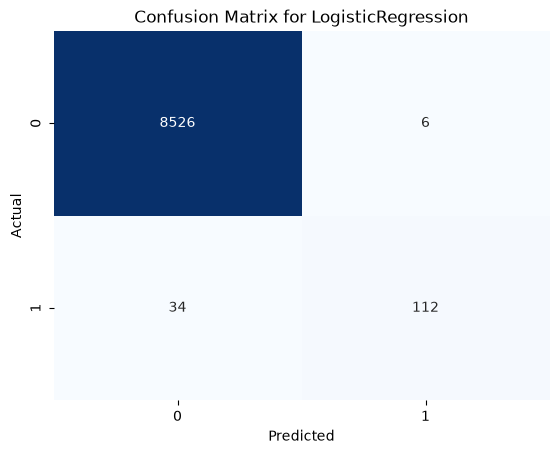

Confusion Matrix:
[[8521   11]
 [  73   73]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      8532
           1       0.87      0.50      0.63       146

    accuracy                           0.99      8678
   macro avg       0.93      0.75      0.81      8678
weighted avg       0.99      0.99      0.99      8678

Accuracy Score:
0.9903203503111316
Y Pred:
[0 0 0 ... 0 0 0]


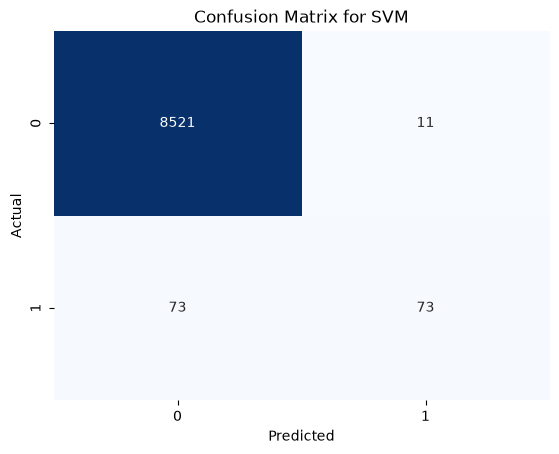

Confusion Matrix:
[[8527    5]
 [ 125   21]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      8532
           1       0.81      0.14      0.24       146

    accuracy                           0.99      8678
   macro avg       0.90      0.57      0.62      8678
weighted avg       0.98      0.99      0.98      8678

Accuracy Score:
0.9850195897672275
Y Pred:
[0 0 0 ... 0 0 0]
Roc Auc:
0.6592642364924315


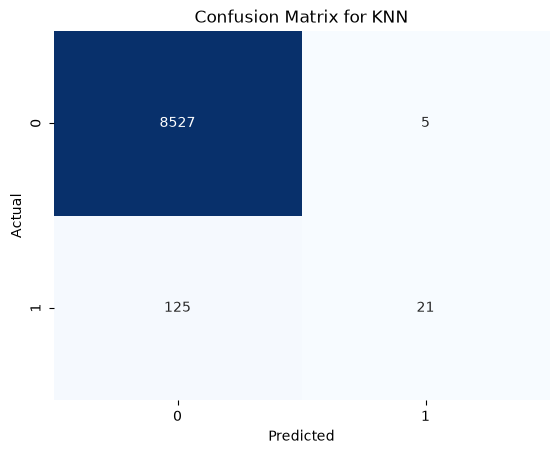

In [8]:
# Visualize correlation heatmap and confusion matrices for all models
fraud_project.visualize_correlation_heatmap()
fraud_project.visualize_all_results()

In [8]:
# Compare accuracies of different models
fraud_project.compare_accuracies()

Confusion Matrix:
[[8528    4]
 [  25  121]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8532
           1       0.97      0.83      0.89       146

    accuracy                           1.00      8678
   macro avg       0.98      0.91      0.95      8678
weighted avg       1.00      1.00      1.00      8678

Accuracy Score:
0.9966582161788431
Y Pred:
[0 0 0 ... 0 0 0]
Roc Auc:
0.9732477730895452


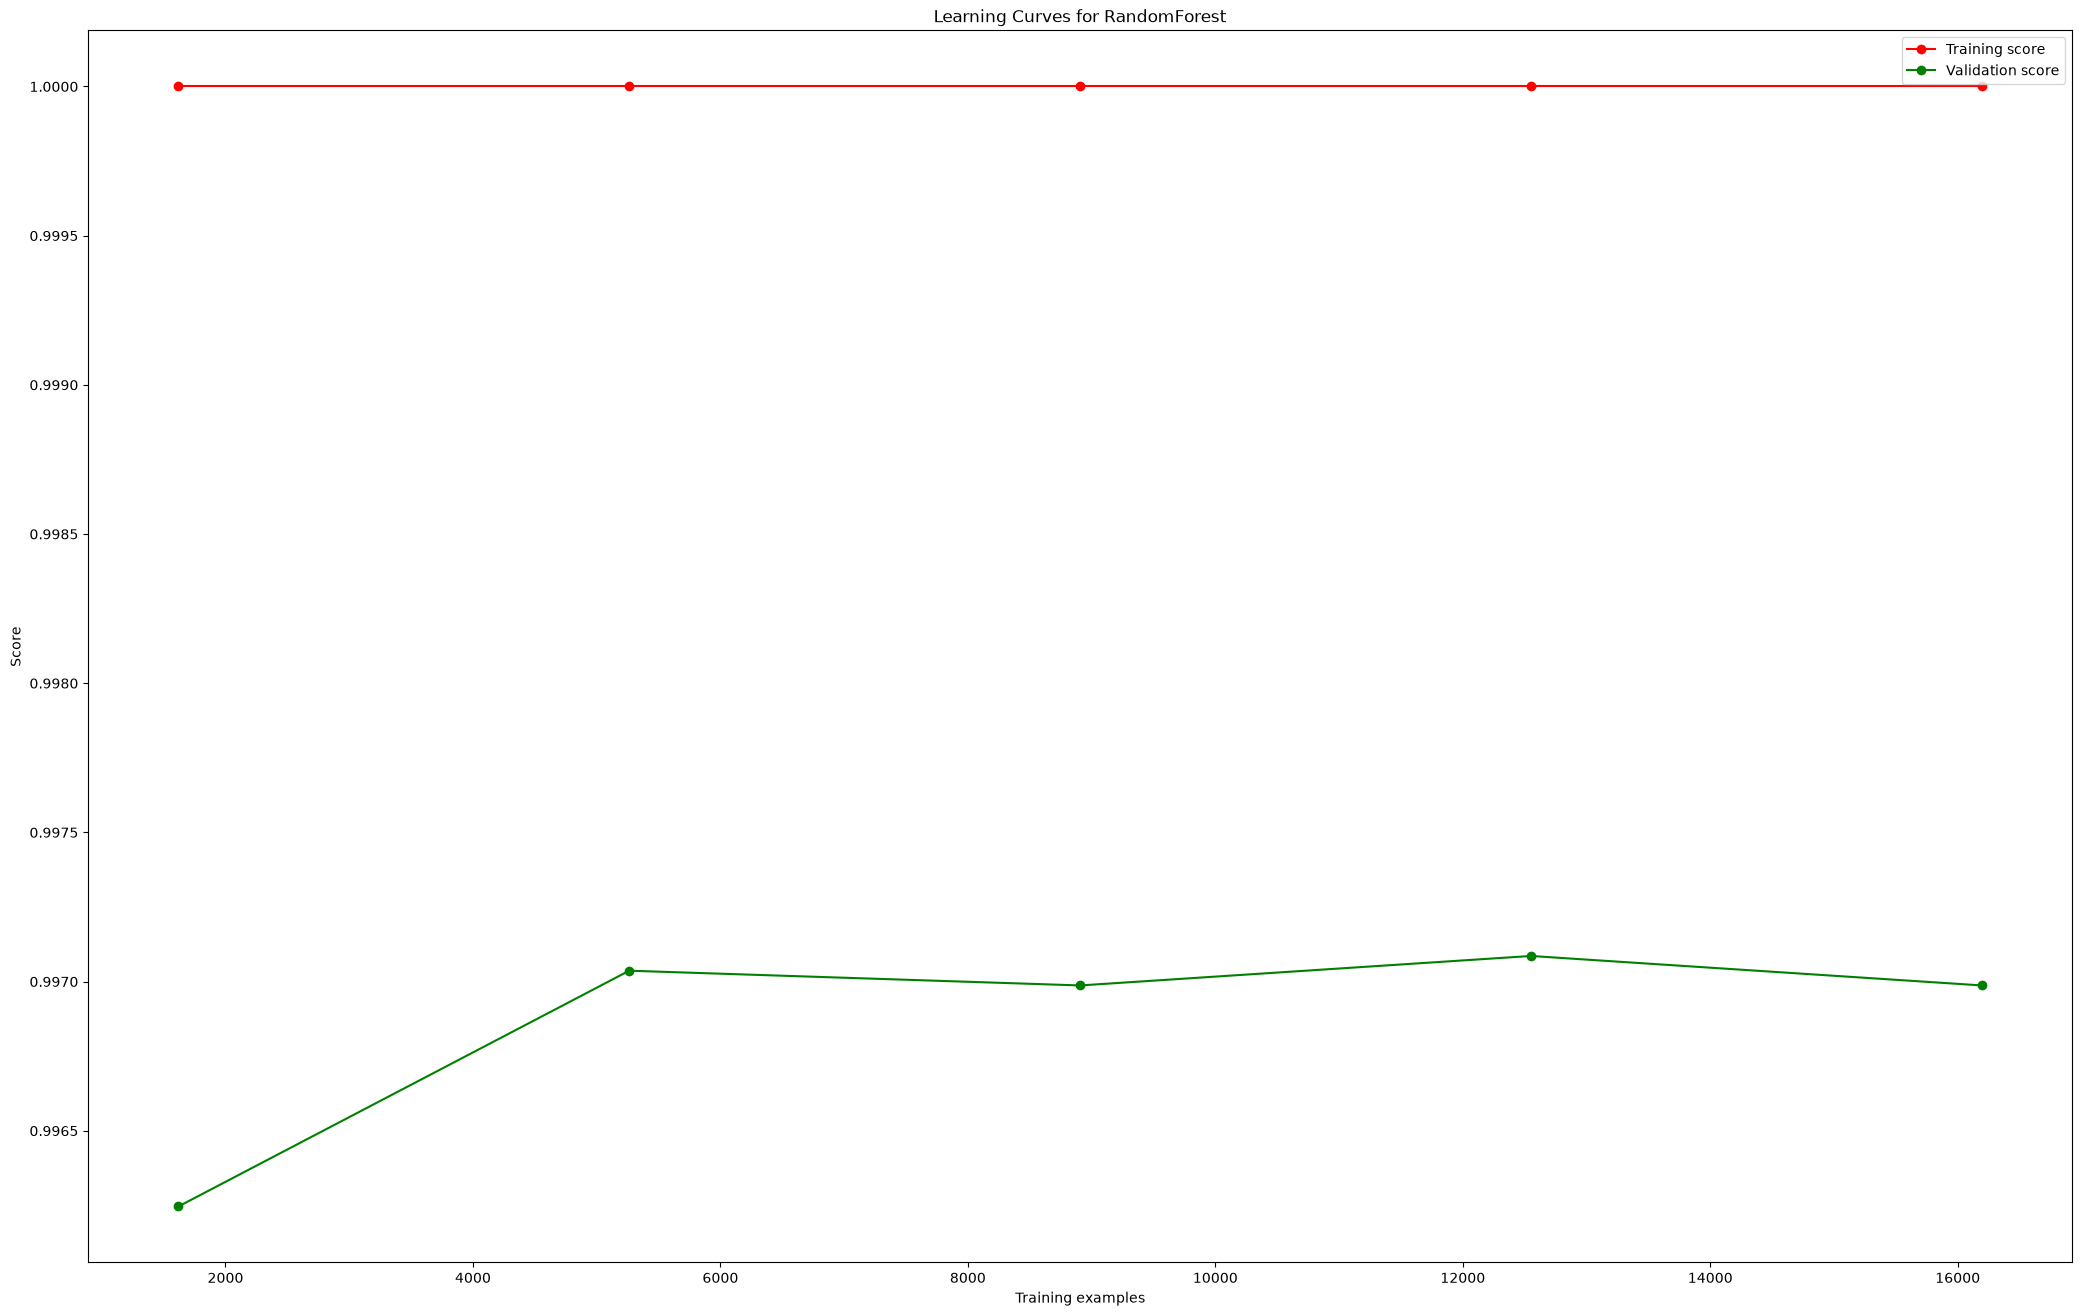

In [9]:
# Print detailed results and learning curves for RandomForest
fraud_project.print_results("RandomForest")
fraud_project.visualize_learning_curves("RandomForest")

In [19]:
# Compare fraud-detection metrics across trained models
model_metrics = fraud_project.summarize_model_metrics()
display(model_metrics.round(4))
fraud_project.select_best_model(model_metrics, metric='fraud_f1')

,accuracy,fraud_precision,fraud_recall,fraud_f1,roc_auc
model,,,,,
RandomForest,0.9967,0.9680,0.8288,0.8930,0.9670
GradientBoosting,0.9968,0.9758,0.8288,0.8963,0.9668
LogisticRegression,0.9954,0.9492,0.7671,0.8485,0.9451
SVM,0.9903,0.8690,0.5000,0.6348,0.8160
KNN,0.9850,0.8077,0.1438,0.2442,0.6593


Best model by fraud_f1: GradientBoosting (0.8963)


'GradientBoosting'

## Why Gradient Boosting?

Gradient Boosting is the current choice because it has the highest accuracy (`0.9968`), fraud precision (`0.9758`), and fraud F1-score (`0.8963`). It matches Random Forest's fraud recall (`0.8288`), so it detects the same proportion of fraudulent transactions while producing fewer false alarms. Random Forest has a very small ROC-AUC advantage, but Gradient Boosting is the better overall model for the current fraud-detection objective.

The next steps are to validate Gradient Boosting on an untouched holdout set, tune the fraud probability threshold based on the cost of missed fraud versus false alarms, save the final model, and test it on new transactions.

In [ ]:
# Save the selected model through the project object
selected_model_name = fraud_project.select_best_model(model_metrics, metric='fraud_f1')
fraud_project.save_model(selected_model_name)

Best model by fraud_f1: GradientBoosting (0.8963)
Selected model: GradientBoosting
Saved to: models/fraud_detection_model.pkl


## MLflow Experiment Tracking

Each trained model is logged as a separate MLflow run with hyperparameters, fraud-focused metrics, evaluation artifacts, and the serialized scikit-learn model. The tracked metrics make model comparison reproducible in the MLflow UI.

In [29]:
# Log one MLflow run for each trained model
mlflow_manager = MLflowExperimentManager(
    min_fraud_f1=0.85,
    min_fraud_recall=0.80
)
mlflow_results = mlflow_manager.log_project_models(fraud_project)
display(mlflow_results.round(4))

2026/09/05 20:19:48 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/05 20:19:48 INFO mlflow.store.db.utils: Updating database tables
2026/09/05 20:19:49 INFO mlflow.tracking.fluent: Experiment with name 'fraud-detection' does not exist. Creating a new experiment.
2026/09/05 20:19:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/05 20:19:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/05 20:20:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/05 20:20:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/05 20:20:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


,run_id,accuracy,fraud_precision,fraud_recall,fraud_f1,roc_auc
model,,,,,,
GradientBoosting,107885e6f74945cbaec83a5e4f41f2b1,0.9968,0.9758,0.8288,0.8963,0.9668
RandomForest,b6397c844a72462db296dc38718b975d,0.9967,0.9680,0.8288,0.8930,0.9670
LogisticRegression,ad8d445c81e54ee1885650ca2431a922,0.9954,0.9492,0.7671,0.8485,0.9451
SVM,6b1d7cef4e28408f8de3cda252e99c72,0.9903,0.8690,0.5000,0.6348,0.8160
KNN,7c3a8fb0106e41709dbfb33133151143,0.9850,0.8077,0.1438,0.2442,0.6593


## Model Registry Promotion

Gradient Boosting is promoted only if it clears the minimum fraud F1 and recall gates. This prevents a model from being registered as the champion solely because it has high overall accuracy on an imbalanced dataset.

In [30]:
# Register and promote the best model when it passes the fraud-metric gate
promotion = mlflow_manager.register_best_model(
    fraud_project,
    metric='fraud_f1'
)
promotion

Successfully registered model 'fraud-detection-model'.
2026/09/05 20:20:17 WARNING mlflow.tracking._model_registry.fluent: Run with id 107885e6f74945cbaec83a5e4f41f2b1 has no artifacts at artifact path 'model', registering model based on models:/m-38374f3cba114f8f97ada8bbb37ad72b instead


Best model by fraud_f1: GradientBoosting (0.8963)


Created version '1' of model 'fraud-detection-model'.


{'model': 'GradientBoosting',
 'run_id': '107885e6f74945cbaec83a5e4f41f2b1',
 'version': 1,
 'model_uri': 'models:/fraud-detection-model@champion',
 'metrics': {'accuracy': 0.9967734501037105,
  'fraud_precision': 0.9758064516129032,
  'fraud_recall': 0.8287671232876712,
  'fraud_f1': 0.8962962962962963,
  'roc_auc': 0.9667982422339106}}

## Load and Test the Exported Model

Create a fresh project object to simulate inference after training. The object loads the exported Gradient Boosting model and evaluates it on the existing held-out transactions.

In [27]:
# Create a fresh inference object and load the exported model
inference_project = FraudDetectionProject(use_local=True)
inference_project.load_model()

inference_results = inference_project.evaluate_predictions(
    fraud_project.X_test,
    fraud_project.y_test
)
print(inference_results['classification_report'])
print(f"Accuracy: {inference_results['accuracy_score']:.4f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8532
           1       0.98      0.83      0.90       146

    accuracy                           1.00      8678
   macro avg       0.99      0.91      0.95      8678
weighted avg       1.00      1.00      1.00      8678

Accuracy: 0.9968
